   user_id      group  converted signup_date device_type         region  \
0   100993  treatment          0  2024-06-21     desktop  North America   
1   105184  treatment          0  2024-06-08      mobile  North America   
2   137104    control          0  2024-01-21      mobile  South America   
3   152520    control          0  2024-03-31      mobile         Europe   
4   113096    control          1  2024-01-10     desktop  North America   

  experiment_id  
0       exp_103  
1       exp_102  
2       exp_103  
3       exp_102  
4       exp_102  

Device Distribution (%):
 group          control  treatment
device_type                      
desktop      50.000000  50.000000
mobile       49.944389  50.055611
tablet       50.182785  49.817215

Conversion Rates:
 group
control      0.102264
treatment    0.116565
Name: converted, dtype: float64

T-test: t=5.6123, p-value=0.0000

Sample Size:
 group
treatment    30009
control      29991
Name: count, dtype: int64


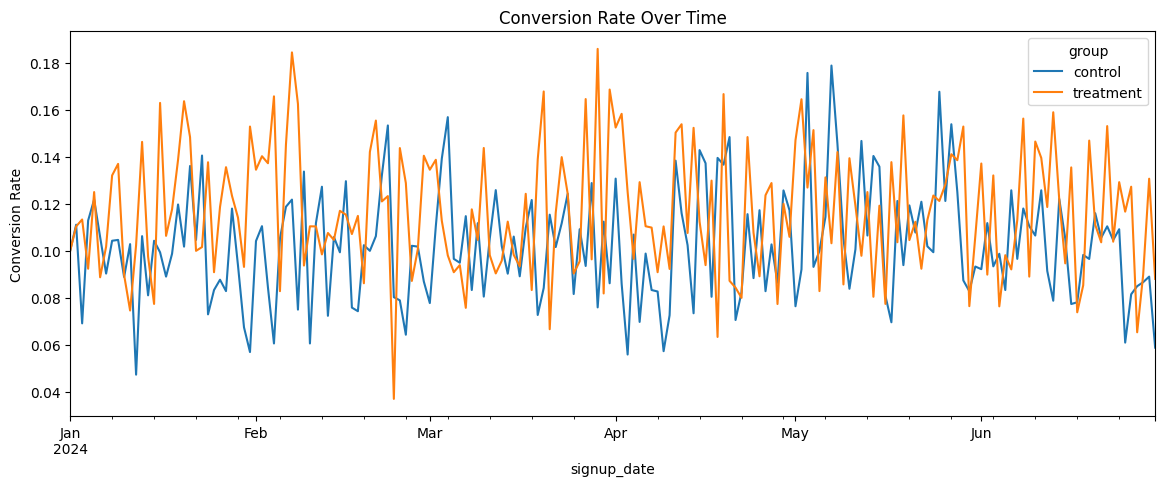


Region Chi-square test: chi2=2.70, p=0.4403
🚩 Statistically significant difference in conversion rate (p < 0.05)
✅ Group sizes are balanced
✅ Region distribution looks fair


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind

# Load your data
df = pd.read_csv("../data/simulated_ab_test_data.csv")

# Preview
print(df.head())

# 1️⃣ Group Balance Check (Device Type)
device_ct = pd.crosstab(df['device_type'], df['group'], normalize='index') * 100
print("\nDevice Distribution (%):\n", device_ct)

# 2️⃣ Conversion Rate Comparison
cr = df.groupby('group')['converted'].mean()
print("\nConversion Rates:\n", cr)

# 3️⃣ T-Test for Conversion Difference
control = df[df['group'] == 'control']['converted']
treatment = df[df['group'] == 'treatment']['converted']
t_stat, p_val = ttest_ind(treatment, control)
print(f"\nT-test: t={t_stat:.4f}, p-value={p_val:.4f}")

# 4️⃣ Sample Size Check
print("\nSample Size:\n", df['group'].value_counts())

# 5️⃣ Conversion by Date (Time Confound Detection)
df['signup_date'] = pd.to_datetime(df['signup_date'])
conversion_by_date = df.groupby(['signup_date', 'group'])['converted'].mean().unstack()
conversion_by_date.plot(figsize=(14,5), title='Conversion Rate Over Time')
plt.ylabel('Conversion Rate')
plt.show()

# 6️⃣ Region Imbalance (Chi-Square Test)
region_table = pd.crosstab(df['region'], df['group'])
chi2, p, dof, expected = chi2_contingency(region_table)
print(f"\nRegion Chi-square test: chi2={chi2:.2f}, p={p:.4f}")

# 🚩 Rule 1: Statistically significant uplift?
if p_val < 0.05:
    print("🚩 Statistically significant difference in conversion rate (p < 0.05)")
else:
    print("✅ No significant conversion difference (p >= 0.05)")

# 🚩 Rule 2: Group size imbalance?
size_ratio = df['group'].value_counts(normalize=True)
if abs(size_ratio['control'] - size_ratio['treatment']) > 0.05:
    print("🚩 Unequal group sizes (imbalance > 5%)")
else:
    print("✅ Group sizes are balanced")

# 🚩 Rule 3: Regional skew?
if p < 0.05:
    print("🚩 Region distribution is significantly imbalanced")
else:
    print("✅ Region distribution looks fair")

# 🚩 Rule 4: Conversion rate spike over time?
# Optional: if rolling avg gap ever exceeds threshold, flag it (add later if needed)

